# Telecom Customer Churn Analysis

## 02: Univariate Analysis

### Objective
This notebook explores the individual characteristics and distributions of variables in the cleaned Telecom Customer Churn dataset.

The univariate analysis includes:

- Examining the distribution of numerical variables
- Analyzing the frequency and proportion of categorical variables
- Identifying skewed distributions and unusual observations
- Understanding customer demographics, service usage, and billing characteristics
- Establishing a baseline understanding of the dataset before analyzing relationships between variables and customer churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style='white', context='notebook', palette='deep')

In [2]:
# Load output from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

churn_df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,True,0,Frazier Park,93225,34.827663,-118.999069,2,...,Credit Card,65.599998,593.299988,0.000000,0,381.510010,974.809998,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,False,0,Glendale,91206,34.162514,-118.203873,0,...,Credit Card,-4.000000,542.400024,38.330002,10,96.209999,610.280029,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,False,0,Costa Mesa,92627,33.645672,-117.922615,0,...,Bank Withdrawal,73.900002,280.850006,0.000000,0,134.600006,415.450012,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,True,0,Martinez,94553,38.014458,-122.115433,1,...,Bank Withdrawal,98.000000,1237.849976,0.000000,0,361.660004,1599.510010,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,True,0,Camarillo,93010,34.227844,-119.079903,3,...,Credit Card,83.900002,267.399994,0.000000,0,22.139999,289.540009,Churned,Dissatisfaction,Network reliability


In [3]:
# Verify if data types were preserved
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        7043 non-null   str     
 1   Gender                             7043 non-null   category
 2   Age                                7043 non-null   Int8    
 3   Married                            7043 non-null   boolean 
 4   Number of Dependents               7043 non-null   Int8    
 5   City                               7043 non-null   str     
 6   Zip Code                           7043 non-null   string  
 7   Latitude                           7043 non-null   float32 
 8   Longitude                          7043 non-null   float32 
 9   Number of Referrals                7043 non-null   Int8    
 10  Tenure in Months                   7043 non-null   Int8    
 11  Offer                              7043 non-null   cat

### Gender
- What categories are present?
- How many customers belong to each category?
- What is the proportion of gender distribution within the customer base?

In [136]:
gender_proportions = (churn_df['Gender'].value_counts(normalize=True)) * 100
gender_proportions

Gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

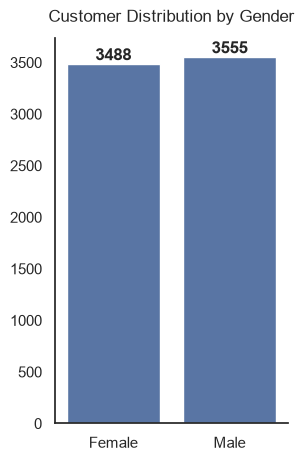

In [137]:
plt.figure(figsize=(3, 5))
ax = sns.countplot(
    data=churn_df,
    x='Gender'
)

ax.bar_label(ax.containers[0], fontweight='bold')

plt.title('Customer Distribution by Gender', pad=12)
plt.xlabel('')
plt.ylabel('')
sns.despine()
plt.show()

The customer population is nearly evenly distributed by gender, with males accounting for approximately 50.5% and females for 49.5%. No indication of substantial gender imbalance in the dataset.

In [138]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        7043 non-null   str     
 1   Gender                             7043 non-null   category
 2   Age                                7043 non-null   Int8    
 3   Married                            7043 non-null   boolean 
 4   Number of Dependents               7043 non-null   Int8    
 5   City                               7043 non-null   str     
 6   Zip Code                           7043 non-null   string  
 7   Latitude                           7043 non-null   float32 
 8   Longitude                          7043 non-null   float32 
 9   Number of Referrals                7043 non-null   Int8    
 10  Tenure in Months                   7043 non-null   Int8    
 11  Offer                              7043 non-null   cat

### Age
- Summary statistics for customers' age. 
- How are customers age distributed?


In [146]:
churn_df['Age'].describe()

count       7043.0
mean     46.509726
std      16.750352
min           19.0
25%           32.0
50%           46.0
75%           60.0
max           80.0
Name: Age, dtype: Float64

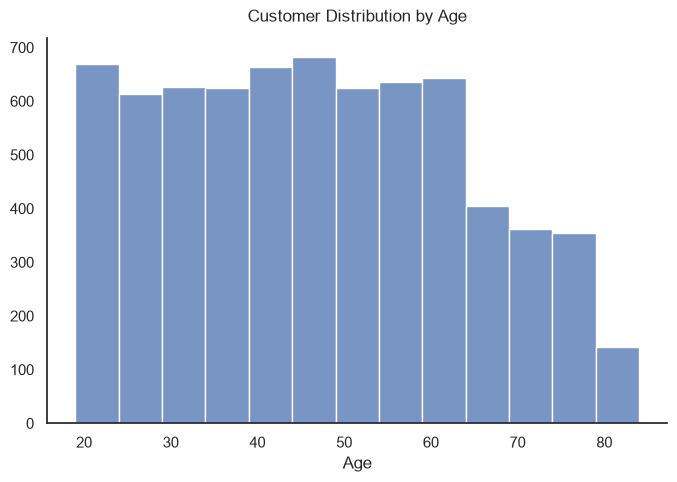

In [162]:
plt.figure(figsize=(8,5))
age_bins = range(19, 85, 5)
sns.histplot(
    data=churn_df,
    x='Age',
    bins=age_bins
)

plt.title('Customer Distribution by Age', pad=12)
plt.xlabel('Age')
plt.ylabel('')
sns.despine()
plt.show()

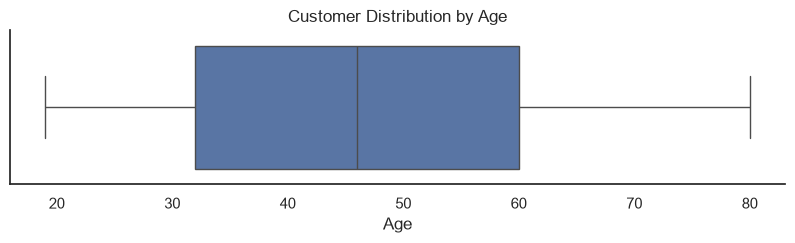

In [166]:
plt.figure(figsize=(10, 2))

sns.boxplot(
    data=churn_df,
    x='Age'
)

plt.title('Customer Distribution by Age')
plt.xlabel('Age')
sns.despine()
plt.show()

Customer ages ranges from 19 to 80 years old, with a median age of 46. The age distribution is relatively even across younger and middle-aged customers, with a noticeable decline in the number of customers beyond approximately 65 years old. No apparent age outliers were identified based on the boxplot.

In [167]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        7043 non-null   str     
 1   Gender                             7043 non-null   category
 2   Age                                7043 non-null   Int8    
 3   Married                            7043 non-null   boolean 
 4   Number of Dependents               7043 non-null   Int8    
 5   City                               7043 non-null   str     
 6   Zip Code                           7043 non-null   string  
 7   Latitude                           7043 non-null   float32 
 8   Longitude                          7043 non-null   float32 
 9   Number of Referrals                7043 non-null   Int8    
 10  Tenure in Months                   7043 non-null   Int8    
 11  Offer                              7043 non-null   cat

### Married
- How many customers are married vs unmarried?
- What percentage of customers does each group represent?

In [171]:
married_percentages = (churn_df['Married'].value_counts(normalize=True)) * 100
married_percentages

Married
False    51.69672
True     48.30328
Name: proportion, dtype: Float64

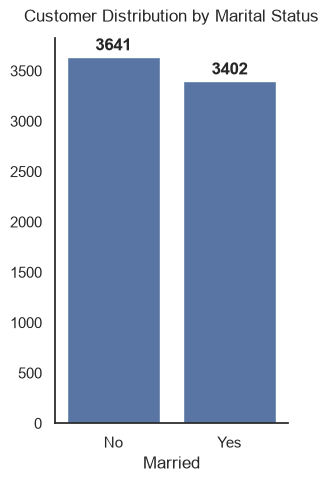

In [185]:
plt.figure(figsize=(3, 5))

ax = sns.countplot(
    data=churn_df,
    x='Married',
    order=[False, True]
)

ax.bar_label(
    ax.containers[0],
    padding=2,
    fontweight='bold'
)
ax.set_xticks([0, 1], ['No', 'Yes'])
plt.title('Customer Distribution by Marital Status', pad=12)
plt.ylabel('')
sns.despine()
plt.show()

The customer population is nearly evenly distributed by marital status, with married customers accounting for approximately 48.3% and unmarried customers for 51.7%. This indicates no substantial marital status imbalance within the dataset.

### Number of Dependents
- What is the average number of dependents per customer?
- How many customers have no dependents?
- How are customers distributed by number of dependents?
- What is the maximum number of dependents reported by a customer?

In [187]:
churn_df['Number of Dependents'].describe()

count      7043.0
mean     0.468692
std      0.962802
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           9.0
Name: Number of Dependents, dtype: Float64

In [188]:
data = churn_df

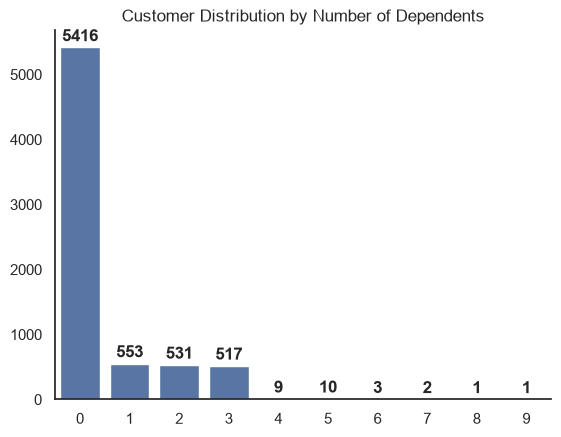

In [205]:
ax = sns.countplot(
    data, x='Number of Dependents'
)

ax.bar_label(
    ax.containers[0],
    padding=2,
    fontweight='bold'
)


plt.title('Customer Distribution by Number of Dependents')
plt.ylabel('')
plt.xlabel('')
sns.despine()
plt.show()

In [207]:
data['Number of Dependents'].value_counts(normalize=True)

Number of Dependents
0     0.76899
1    0.078518
2    0.075394
3    0.073406
5     0.00142
4    0.001278
6    0.000426
7    0.000284
9    0.000142
8    0.000142
Name: proportion, dtype: Float64

The majority of customers have no declared dependents, accounting for approximately 77% of the customer base. The distribution is heavily right-skewed, with relatively few customers reporting more than three dependents.